# Model Evaluation — Loan Approval Prediction

Loads the pipelines trained in `03_Modeling.ipynb` and evaluates them on the held-out test set: confusion matrices, ROC and precision-recall curves, threshold optimization, feature importance, and SHAP-based explanations for the winning model. Closes with the parts of this project that are easy to skip but shouldn't be -- limitations, result stability, and the business perspective behind the modeling choices. Also regenerates `outputs/reports/model_results.csv`, the report consumed by the README results table.

In [1]:
import sys

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    !git clone -q https://github.com/AnaNicuesa/loan-approval-prediction.git
    %cd loan-approval-prediction
    %pip install -q -r requirements.txt

In [2]:
import sys
from pathlib import Path


def find_project_root(start: Path) -> Path:
    path = start.resolve()
    for _ in range(4):
        if (path / "src").exists() and (path / "data").exists():
            return path
        path = path.parent
    raise FileNotFoundError("Could not locate project root from " + str(start))


PROJECT_ROOT = find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

In [3]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import RocCurveDisplay

from src.train import load_model
from src.evaluate import (
    evaluate_thresholds,
    plot_confusion_matrix,
    plot_precision_recall,
    plot_feature_importance,
)
from src.explain import (
    plot_global_importance,
    plot_summary_beeswarm,
    plot_waterfall,
    mean_shap_by_value,
    compare_with_impurity_importance,
    get_local_factors,
)
from src.utils import (
    PROCESSED_DATA_DIR,
    REPORTS_DIR,
    FIGURES_DIR,
    TARGET,
    NUMERIC_FEATURES,
    CATEGORICAL_FEATURES,
    EXAMPLE_APPLICANTS,
    timer,
    ensure_directories,
)
from src.predict import build_input_frame

ensure_directories()
pd.set_option("display.max_columns", None)

## 1. Loading the test set and trained pipelines

In [4]:
test_df = pd.read_csv(PROCESSED_DATA_DIR / "test.csv")
feature_columns = NUMERIC_FEATURES + CATEGORICAL_FEATURES
X_test, y_test = test_df[feature_columns], test_df[TARGET]

model_names = ["logistic_regression", "random_forest", "xgboost"]
models = {name: load_model(name) for name in model_names}
list(models.keys())

['logistic_regression', 'random_forest', 'xgboost']

## 2. Metrics for every model

`training_time` comes from the hyperparameter search in `03_Modeling.ipynb` and is read from the report already saved there; `prediction_time` is measured fresh below since it only depends on the final fitted pipeline, not on how it was tuned.

In [5]:
report_df = pd.read_csv(REPORTS_DIR / "model_results.csv").set_index("model")

prediction_times = {}
for name, model in models.items():
    with timer() as pred_timer:
        model.predict(X_test)
    prediction_times[name] = pred_timer["seconds"]

report_df["prediction_time"] = pd.Series(prediction_times)
report_df = report_df.sort_values("roc_auc", ascending=False)

report_df.reset_index().to_csv(REPORTS_DIR / "model_results.csv", index=False)
print(f"Updated report at {(REPORTS_DIR / 'model_results.csv').relative_to(PROJECT_ROOT)}")
report_df

Updated report at outputs/reports/model_results.csv


,accuracy,precision,recall,f1,roc_auc,cv_roc_auc,training_time,prediction_time
model,,,,,,,,
random_forest,0.803922,0.827160,0.917808,0.870130,0.818139,0.750813,5.399633,0.014109
xgboost,0.813725,0.864865,0.876712,0.870748,0.775626,0.749526,1.428624,0.014636
logistic_regression,0.833333,0.825581,0.972603,0.893082,0.745867,0.703582,1.065885,0.004642


## 3. Confusion matrix — best model

Best model by test ROC AUC: random_forest


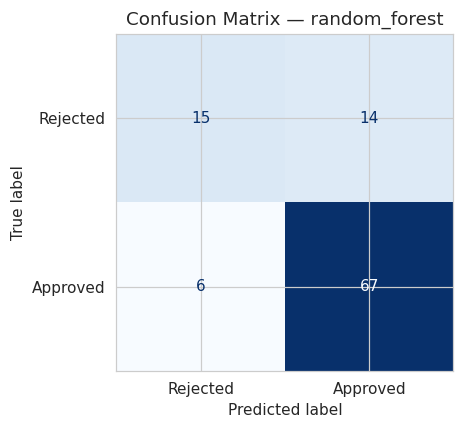

In [6]:
best_model_name = report_df.index[0]
best_model = models[best_model_name]
y_pred_best = best_model.predict(X_test)
y_proba_best = best_model.predict_proba(X_test)[:, 1]

print(f"Best model by test ROC AUC: {best_model_name}")
plot_confusion_matrix(y_test, y_pred_best, best_model_name)
plt.show()

## 4. ROC curve — all three models

Plotting all three on the same axes makes the gap (or lack of one) between models easier to judge than reading AUC values off a table.

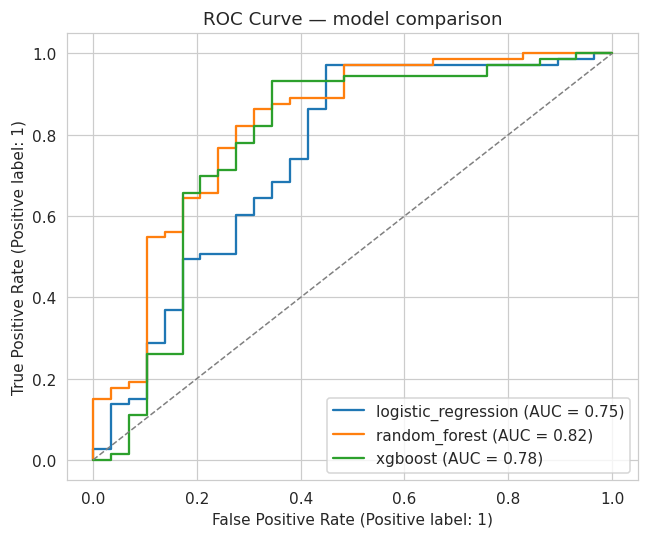

In [7]:
fig, ax = plt.subplots(figsize=(6, 5))
for name, model in models.items():
    y_proba = model.predict_proba(X_test)[:, 1]
    RocCurveDisplay.from_predictions(y_test, y_proba, ax=ax, name=name)
ax.plot([0, 1], [0, 1], linestyle="--", color="grey", linewidth=1)
ax.set_title("ROC Curve — model comparison")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "roc_curve_comparison.png")
plt.show()

## 5. Precision-recall curve — best model

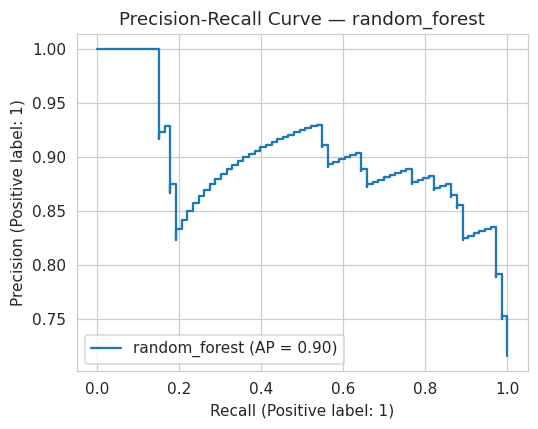

In [8]:
plot_precision_recall(y_test, y_proba_best, best_model_name)
plt.show()

## 6. Threshold optimization

Every metric so far -- ROC AUC especially -- evaluates how well the model *ranks* applicants by predicted probability, independent of any specific decision rule. ROC AUC would be exactly the same whether the bank approves the top 10% of applicants or the top 90%, because it's measuring the ranking's quality across every possible cutoff at once.

The **threshold** is where ranking turns into an actual decision: "approve if predicted probability >= T." Changing T doesn't change the model or its ROC AUC at all -- it changes which applicants get approved. This section fixes the model and sweeps T instead.

In [9]:
threshold_results = evaluate_thresholds(y_test, y_proba_best, thresholds=(0.3, 0.4, 0.5, 0.6, 0.7))
threshold_results

,threshold,precision,recall,f1,accuracy,true_positives,false_positives,false_negatives,true_negatives
0,0.3,0.825581,0.972603,0.893082,0.833333,71,15,2,14
1,0.4,0.833333,0.958904,0.891720,0.833333,70,14,3,15
2,0.5,0.827160,0.917808,0.870130,0.803922,67,14,6,15
3,0.6,0.864865,0.876712,0.870748,0.813725,64,10,9,19
4,0.7,0.883333,0.726027,0.796992,0.735294,53,7,20,22


Reading the sweep on this test set (102 applicants, of whom 73 were actually approved):

- **Lower threshold (0.3-0.4)**: recall stays close to 0.96-0.97 -- almost every applicant who should be approved is approved -- but precision is lower, meaning more of the approvals are applicants who will default. False positives sit at 14-15.
- **Default threshold (0.5)**: the balanced middle ground scikit-learn gives you for free, not necessarily the right business answer.
- **Higher threshold (0.6-0.7)**: precision climbs toward 0.86-0.88 -- approvals are more reliably good -- but recall drops sharply at 0.7 (0.73), rejecting one in four applicants who actually deserved approval. False positives fall from 14 to 7, but false negatives more than triple, from 6 to 20.

**Which threshold would a bank actually choose?** It depends on which mistake is more expensive:

- A **false positive** here (predicted approved, should have been rejected) means lending to someone who is more likely to default -- the cost is a chunk of the principal plus the lost interest income, potentially the whole loan amount.
- A **false negative** (predicted rejected, should have been approved) means turning away a creditworthy customer -- the cost is the lost interest income on one loan, and possibly the customer relationship, but no principal is at risk.

Because a default typically costs more than one loan's worth of foregone interest, most retail lending settings would lean toward a **higher threshold** (0.6, sometimes higher) than the 0.5 default, deliberately trading some recall for better precision. The exact number is a business decision informed by this table, not a modeling one -- it belongs with risk and finance stakeholders, not buried as a hardcoded default in code.

## 7. Feature importance — best model

Consistent with the correlation analysis in the EDA notebook, `credit_history` is expected to be the single largest driver of the prediction regardless of which model wins.

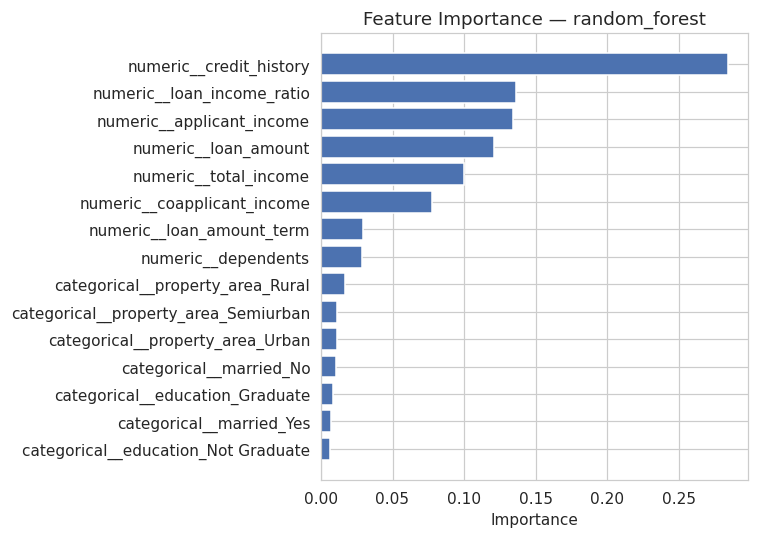

In [10]:
plot_feature_importance(best_model, best_model_name)
plt.show()

## 8. SHAP — global feature impact

`feature_importances_` tells us which splits reduce impurity most, but it says nothing about the *direction* of the effect or how it varies per applicant. SHAP (SHapley Additive exPlanations) decomposes each individual prediction into per-feature contributions that add up exactly to the difference between that prediction and the model's average output. Contributions are computed in the same transformed space the classifier sees, then summed back onto the original columns — one-hot dummies for `property_area`, for example, collapse into a single `property_area` contribution.

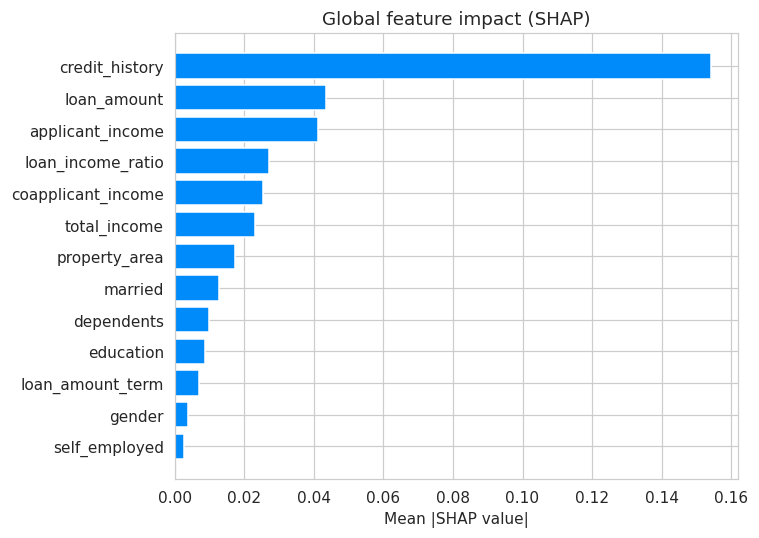

In [11]:
plot_global_importance(best_model, X_test, max_display=13)
plt.show()

The bar chart above only shows *how much* each feature matters on average, not which direction it pushes the prediction. The beeswarm plot below adds that: every dot is one test applicant, its horizontal position is that applicant's SHAP value for the feature, and its color is the applicant's actual value for that feature (dark blue and yellow follow whatever `matplotlib` colormap SHAP defaults to for low vs. high values; for a two-level categorical like `married`, that just means one color per category).

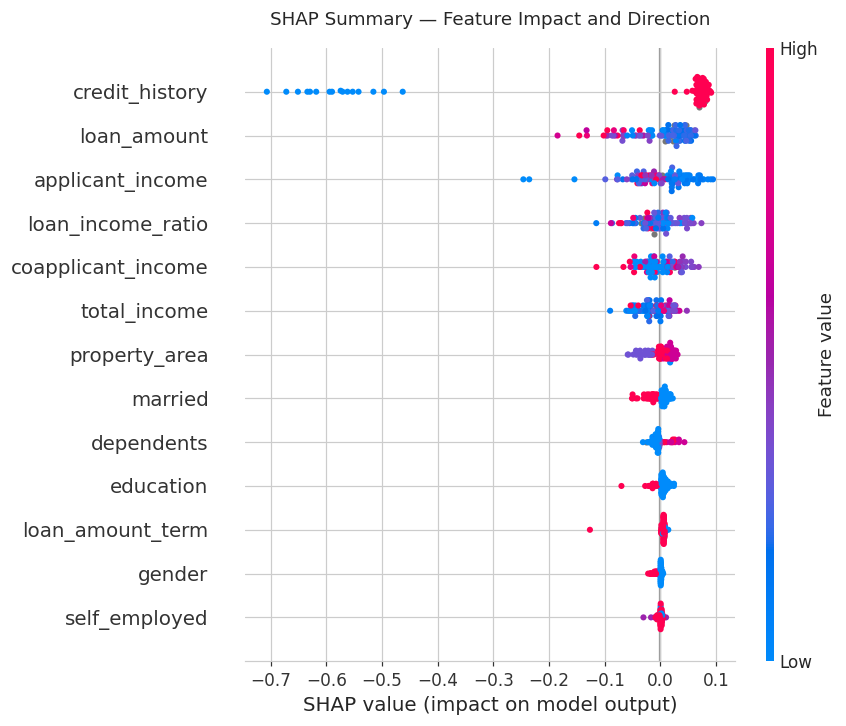

In [12]:
plot_summary_beeswarm(best_model, X_test, max_display=13)
plt.show()

### What actually pushes a prediction toward approval or rejection

A single sample-wide average SHAP value is misleading for a feature like `credit_history`: the effect is large but flips sign depending on the value, so the two directions cancel out in a plain mean. Grouping by the feature's actual value avoids that and gives an unambiguous answer.

In [13]:
for feature in ["credit_history", "property_area"]:
    print(f"Mean SHAP contribution by {feature}:")
    print(mean_shap_by_value(best_model, X_test, feature))
    print()

Mean SHAP contribution by credit_history:
1.0    0.073852
0.0   -0.585991
dtype: float64

Mean SHAP contribution by property_area:


Semiurban    0.019873
Urban        0.001661
Rural       -0.029405
dtype: float64



- **Credit history** dominates everything else: a positive credit history contributes roughly +0.07 to the predicted probability of approval on average, while a negative one drags it down by more than half — consistent with the ~80% vs. ~11% approval rates seen in the EDA notebook.
- **Property area** has a much smaller but consistent effect: Semiurban applicants get a small positive push, Rural applicants a small negative one.
- Income, loan amount, and the engineered ratios show up with moderate, applicant-dependent effects in the beeswarm plot rather than one dominant direction — affordability matters, but it's a secondary signal behind credit history.

## 9. SHAP vs. built-in feature importance

Both methods are computed for the same fitted Random Forest, so any disagreement comes from what each one actually measures, not from a different model.

In [14]:
comparison = compare_with_impurity_importance(best_model, X_test)
comparison

,mean_abs_shap,impurity_importance,shap_rank,impurity_rank
credit_history,0.154213,0.284020,1,1
loan_amount,0.043443,0.120887,2,4
applicant_income,0.041315,0.134453,3,3
loan_income_ratio,0.027111,0.136539,4,2
coapplicant_income,0.025441,0.077798,5,6
total_income,0.022995,0.099806,6,5
property_area,0.017398,0.039648,7,7
married,0.012728,0.017467,8,10
dependents,0.009867,0.028494,9,9
education,0.008768,0.014562,10,11


**Why SHAP is more informative here:**

- **Direction, not just magnitude.** Impurity importance says `credit_history` is useful for splitting; it can't say whether having good credit *helps or hurts*. SHAP does — that's the entire content of the beeswarm plot above.
- **Consistent units.** SHAP values are expressed in the same units as the model output (predicted probability of approval), so a value of `+0.07` is directly interpretable. Impurity reduction has no such natural scale and isn't comparable across models.
- **Per-instance, not just per-model.** Impurity importance is a single global number per feature. SHAP gives every applicant their own explanation, which is what makes the waterfall plots in the next section — and the explanation shown in the Streamlit app — possible at all.
- **Less bias toward high-cardinality splits.** Impurity-based importance tends to inflate features that give the tree more places to split (which can include one-hot encoded categoricals with several levels). SHAP's Shapley-value attribution doesn't have that structural bias.

That said, the two mostly agree on ranking here (`shap_rank` vs. `impurity_rank` above track closely), which is a useful cross-check: two different attribution methods pointing at `credit_history` as the dominant feature is stronger evidence than either one alone.

## 10. Local explainability — three representative applicants

The bar and beeswarm plots describe the model on average. In practice, what a loan officer — or an applicant — actually wants is: *why did **this** application get this decision?* The three profiles below are the same ones sanity-checked in `05_Streamlit_Demo.ipynb`, defined once in `src/utils.py` so both notebooks refer to the exact same applicants.

In [15]:
for name, applicant in EXAMPLE_APPLICANTS.items():
    frame = build_input_frame(**applicant)
    probability = best_model.predict_proba(frame)[0, 1]
    print(f"--- {name} (predicted probability of approval: {probability:.3f}) ---")

    increasing, decreasing = get_local_factors(best_model, frame, top_n=4)
    print("  Factors that increased approval probability:")
    for feature, value, shap_value in increasing:
        print(f"    {feature} = {value}  (+{shap_value:.3f})")
    print("  Factors that decreased approval probability:")
    for feature, value, shap_value in decreasing:
        print(f"    {feature} = {value}  ({shap_value:.3f})")
    print()

--- strong_applicant (predicted probability of approval: 0.948) ---
  Factors that increased approval probability:
    credit_history = 1.0  (+0.075)
    loan_amount = 120  (+0.063)
    coapplicant_income = 2000  (+0.030)
    total_income = 8000  (+0.025)
  Factors that decreased approval probability:
    applicant_income = 6000  (-0.017)
    dependents = 0  (-0.004)

--- weak_applicant (predicted probability of approval: 0.135) ---


  Factors that increased approval probability:
    dependents = 3  (+0.026)
    loan_amount_term = 360  (+0.002)
    self_employed = Yes  (+0.000)
  Factors that decreased approval probability:
    credit_history = 0.0  (-0.456)
    loan_amount = 280  (-0.047)
    total_income = 1800  (-0.030)
    property_area = Rural  (-0.017)

--- borderline_applicant (predicted probability of approval: 0.926) ---
  Factors that increased approval probability:
    credit_history = 1.0  (+0.086)
    applicant_income = 3200  (+0.065)
    loan_amount = 110  (+0.033)
    coapplicant_income = 1500  (+0.026)
  Factors that decreased approval probability:
    loan_income_ratio = 0.023404255319148935  (-0.013)
    total_income = 4700  (-0.012)
    dependents = 1  (-0.006)



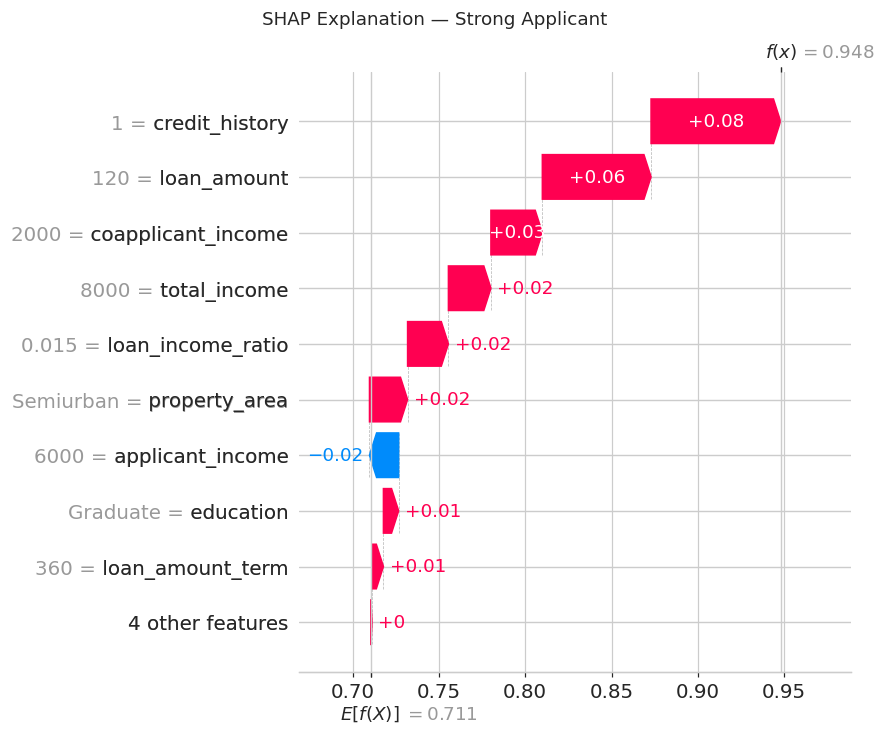

In [16]:
strong_frame = build_input_frame(**EXAMPLE_APPLICANTS["strong_applicant"])
plot_waterfall(best_model, strong_frame, title="SHAP Explanation — Strong Applicant")
plt.show()

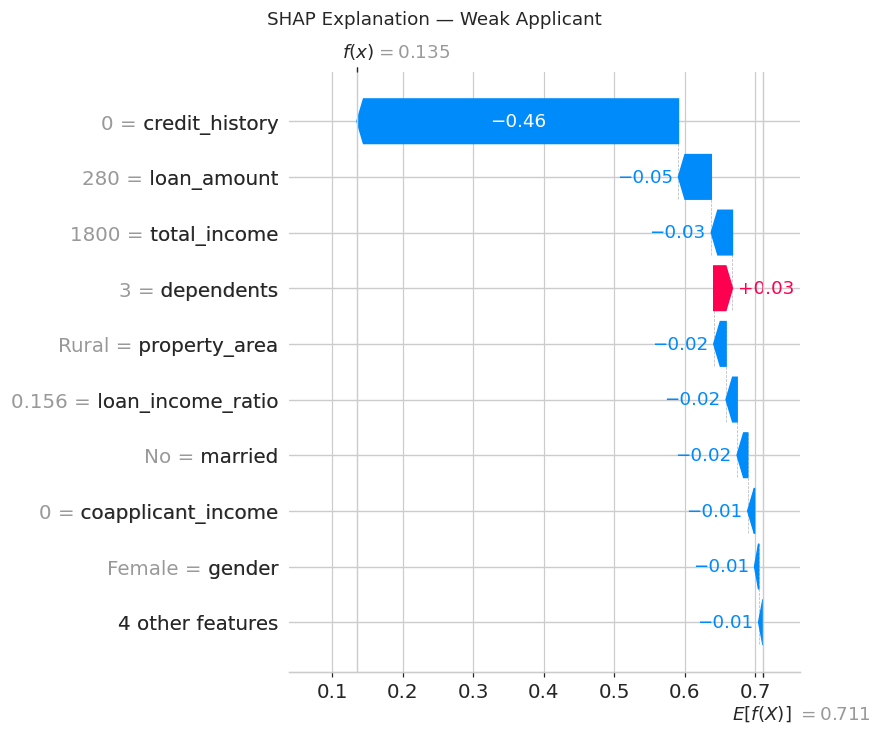

In [17]:
weak_frame = build_input_frame(**EXAMPLE_APPLICANTS["weak_applicant"])
plot_waterfall(best_model, weak_frame, title="SHAP Explanation — Weak Applicant")
plt.show()

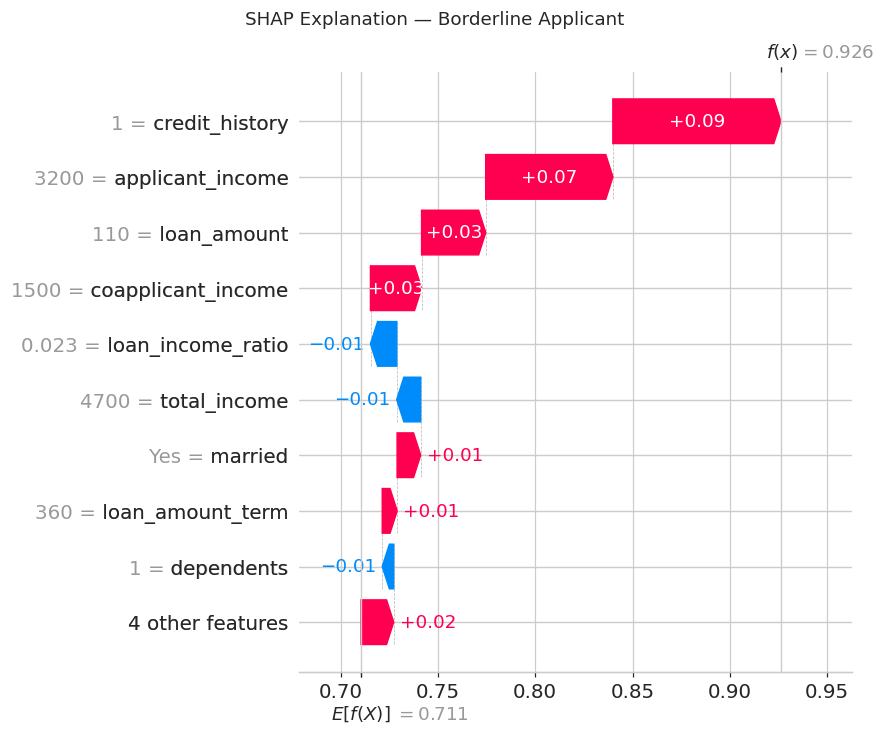

In [18]:
borderline_frame = build_input_frame(**EXAMPLE_APPLICANTS["borderline_applicant"])
plot_waterfall(best_model, borderline_frame, title="SHAP Explanation — Borderline Applicant")
plt.show()

The borderline applicant turns out less ambiguous than expected: credit history, applicant income, and loan amount all push toward approval, landing the prediction at 93% rather than close to the decision boundary. The more interesting detail is in the decreasing factors -- `loan_income_ratio` and `total_income` pull slightly *against* approval even though `applicant_income` itself pushes *for* it. Since `total_income` is engineered from `applicant_income` plus `coapplicant_income`, these three features are correlated by construction, and SHAP can split credit for the same underlying signal across them in ways that look inconsistent at a glance. That is a real limitation to be aware of, not a bug: attributions are only as separable as the features are independent, and it's worth calling out explicitly rather than over-reading a small negative number next to `total_income`.

## 11. Important caveat: this explains the model, not the world

SHAP values describe what the **model** learned from historical data — they are not evidence of a causal relationship in the real world. A large positive SHAP value for `credit_history` means the model relies heavily on it to produce its output, given the patterns in this dataset. It does **not** mean that artificially changing an applicant's credit history would cause that same change in outcome for a real applicant, or that credit history *causes* creditworthiness in a mechanistic sense.

In particular:

- The training data reflects **past approval decisions**, which may themselves encode historical bias, inconsistent underwriting standards, or measurement error — SHAP will faithfully explain those patterns along with any genuine signal.
- Correlated features can mislead a naive reading. `married` and `total_income` are correlated (a coapplicant's income is only nonzero when there generally is a partner), so part of what looks like a "marital status effect" may really be an income effect routed through a correlated variable.
- This analysis says nothing about **counterfactual fairness** — whether the outcome for a specific applicant would have been different had one attribute alone been changed, holding everything else about their real situation fixed.

Any use of this model or its explanations to inform an actual lending decision would need a causal and legal review well beyond what SHAP alone can provide.

## 12. Fairness considerations

Gender, marital status, and number of dependents are all present in this dataset and are exactly the kind of attributes that require care in a real lending context — several are directly or indirectly protected characteristics under fair-lending regulation (e.g. the U.S. Equal Credit Opportunity Act prohibits credit discrimination based on sex and marital status). The question worth asking before deploying anything like this: **how much do these attributes actually move the model's predictions?**

In [19]:
for feature in ["gender", "married", "dependents"]:
    print(f"Mean SHAP contribution by {feature}:")
    print(mean_shap_by_value(best_model, X_test, feature))
    print()

print("For reference, mean |SHAP| ranking (higher = more influence on the prediction):")
comparison[["mean_abs_shap"]]

Mean SHAP contribution by gender:
Male      0.001537
Female   -0.010216
dtype: float64

Mean SHAP contribution by married:


Yes    0.009123
No    -0.018750
dtype: float64

Mean SHAP contribution by dependents:
2.0    0.026158
3.0    0.014255
1.0   -0.004541
0.0   -0.008267
dtype: float64

For reference, mean |SHAP| ranking (higher = more influence on the prediction):


,mean_abs_shap
credit_history,0.154213
loan_amount,0.043443
applicant_income,0.041315
loan_income_ratio,0.027111
coapplicant_income,0.025441
total_income,0.022995
property_area,0.017398
married,0.012728
dependents,0.009867
education,0.008768


**Reading these numbers:**

- `gender` has the *lowest* mean |SHAP| of any feature in the model — its effect on any individual prediction is close to negligible.
- `married` and `dependents` sit in the middle of the ranking with a small but non-zero effect (a few hundredths of a probability point), well below `credit_history`, `loan_amount`, or the income-based features.
- None of the three shows an effect large enough to be the deciding factor in a borderline case on its own, but "small on average" does not mean "zero for every applicant," and a regulator or auditor would rightly want per-applicant evidence, not just an aggregate.

**Risks worth flagging in a real deployment:**

- **Direct disparate treatment.** Even a small direct effect from `gender` or `married` is legally risky in lending contexts covered by ECOA/Regulation B (US) or equivalent equal-treatment law elsewhere. The safest default is to exclude these fields from the feature set entirely unless there's a specific, defensible reason to include them.
- **Proxy discrimination.** Removing a sensitive attribute doesn't guarantee fairness — `total_income` and `coapplicant_income` can act as proxies for `married` (a coapplicant typically implies a partner), so bias can persist through correlated features even after the sensitive column itself is dropped.
- **Historical bias in the label.** If the training labels reflect past human underwriting decisions, any bias in those decisions gets learned by the model regardless of what SHAP reports about individual features.
- **No causal fairness guarantee.** As noted above, a small SHAP value does not prove the feature is causally irrelevant, and a large one does not prove illegal discrimination — this analysis is a starting point for an audit, not a substitute for one involving legal and compliance review.

For this portfolio project the fields are kept for demonstration purposes (the original dataset includes them), but a production version aimed at real lending decisions should not ship without this review.

## 13. How I would explain SHAP to a recruiter or interviewer

A short version that works well out loud:

> "SHAP comes from cooperative game theory — specifically, Shapley values, which were originally designed to fairly split a payout among players in a game based on how much each one actually contributed. Here, the 'game' is one prediction, the 'players' are the input features, and the 'payout' is the difference between that prediction and the model's average output. SHAP asks: if I add features one at a time in every possible order and average the effect, how much does each feature contribute? That's what makes the attributions additive — they sum exactly to the model's output — and consistent, meaning a feature that matters more never gets a smaller share of the credit.

> I used it for two things: a global view, averaging contributions across the test set to see which features the model leans on most, and a local view, explaining one applicant's prediction at a time — which is what actually gets exposed in the app, since 'approved, 82% confidence' is a lot less useful to an applicant than 'approved mainly because of credit history and stable income, despite a smaller loan-to-income ratio.'

> I'd also flag the limitation up front rather than wait to be asked: this explains what the *model* is doing, not what's true about the world. It's a debugging and transparency tool, not a causal claim, and I specifically checked whether sensitive attributes like gender or marital status were carrying meaningful weight before considering this anywhere near production-ready."

This is also a natural place to bring up trade-offs if asked: SHAP's exact computation is exponential in the number of features in general, which is why tree-based models use `TreeExplainer` — a polynomial-time algorithm that exploits tree structure instead of brute-forcing every feature subset.

## 14. Limitations

Worth stating plainly rather than leaving implicit:

- **Small dataset.** 563 raw rows, ~510 after cleaning, split into a 408-row training set and a 102-row test set. That's enough to demonstrate a full pipeline, not enough to be confident the tuned hyperparameters would hold up on a materially different population.
- **Public Kaggle-style dataset.** This is the well-known loan approval dataset used widely for teaching purposes. It reflects one lender's historical decisions in an unspecified market and time period -- it is not a claim about lending in general.
- **Few available features.** No credit score, existing debt, employment history/tenure, or repayment history -- exactly the kind of information a real underwriting model would have and this one doesn't. `credit_history` here is a single binary flag, not a score.
- **Possible selection bias.** The dataset only contains applications that were actually processed and recorded; it says nothing about people who never applied, or applications that were withdrawn or lost before a decision was recorded.
- **No temporal validation.** The train/test split is a random stratified split, not a time-based one. In production, applicant behavior and macroeconomic conditions drift over time, and a model validated on a random split can look better than it would on genuinely out-of-time future applications.
- **No production monitoring.** There is no mechanism here for tracking prediction drift, feature drift, or outcome drift after deployment -- see the Production Readiness section of `05_Streamlit_Demo.ipynb` for what that would require.

None of this invalidates the exercise -- it's a legitimate, fully reproducible modeling pipeline -- but it does mean the specific numbers (0.818 ROC AUC, etc.) should be read as *what this pipeline achieves on this dataset*, not as a general claim about how well this approach would work on a bank's real portfolio.

## 15. Validation and stability of these results

Every metric in this notebook comes from a single 80/20 train/test split of a 510-row dataset -- the test set is only 102 applicants. With a sample that small, metrics computed on it carry real sampling noise: a handful of different applicants landing in the test set by chance could shift ROC AUC by a few hundredths, which is the same order of magnitude as some of the gaps between models reported above.

That doesn't mean the results are unreliable, but it does mean the precise ranking between Random Forest (0.818) and XGBoost (0.776) should be treated as "Random Forest is very likely at least as good, probably better" rather than "Random Forest is definitively 0.04 AUC points better forever." The cross-validation scores from `03_Modeling.ipynb` (`cv_roc_auc`, averaged over 5 folds during tuning) are a more stable estimate than any single test-set number, precisely because they average over multiple splits instead of relying on one.

In a real deployment, I would not treat this single split as final evidence. I'd want:

- **Repeated cross-validation** (e.g. 5-fold repeated 10 times with different shuffles) to get a distribution of scores per model instead of one point estimate, and to check whether the model ranking is stable across repeats or just an artifact of this particular split.
- **More data** before trusting the tuned hyperparameters, since 408 training rows is a small budget to tune multiple hyperparameters per model without risking mild overfitting to the validation folds themselves.
- **A confidence interval or bootstrap estimate** around the headline ROC AUC number before quoting it to a non-technical stakeholder as if it were exact.

None of this changes the modeling decisions made in this project -- it's not worth re-running everything with repeated CV for a 510-row demo dataset -- but it is the honest caveat that belongs next to any of these numbers before they're used to justify a real decision.

## 16. Business perspective

Stepping back from metrics: what does this model actually do in a lending context, and what is it worth getting wrong?

- **Approving a loan** means the bank commits capital to a borrower today in exchange for interest payments over the loan term. It's a bet that the applicant will repay.
- **Cost of approving a high-risk applicant who defaults**: potentially the entire outstanding principal, not just the interest -- by far the more expensive mistake in absolute terms. This is the false positive from Section 6.
- **Cost of rejecting a creditworthy applicant**: the lost interest income on that one loan, and a worse customer experience that may push a good customer to a competitor -- real, but smaller and more recoverable than a default. This is the false negative from Section 6.
- That asymmetry is exactly why Section 6 leans toward a higher decision threshold than the 0.5 default: in most retail lending settings, a false positive costs more than a false negative, so the threshold should be tuned to reflect that, not left at whatever scikit-learn defaults to.

**Why this should be decision support, not a decision-maker.** A model trained on 510 historical rows, with no credit score, no debt information, and no view of anything that happened after the loan was issued, is not a complete picture of an applicant. It's a useful, fast, consistent prior — not a verdict. In practice that means:

- Borderline predictions (see the borderline applicant in Section 10) are exactly the cases that should be routed to a human underwriter, not auto-decided.
- The SHAP explanation is there so a loan officer can sanity-check *why* the model leans a particular way, not just accept a probability at face value.
- Any real deployment needs a human override path, an audit trail, and the fairness review flagged in Section 12 -- a model this size replacing human judgment entirely would be underwriting risk with insufficient information.

## 17. Summary

In [20]:
best_row = report_df.loc[best_model_name]
print(
    f"{best_model_name} is the strongest performer on the held-out test set: "
    f"ROC AUC {best_row['roc_auc']:.3f}, F1 {best_row['f1']:.3f}, "
    f"precision {best_row['precision']:.3f}, recall {best_row['recall']:.3f}."
)
print(
    "Feature importance confirms what the EDA suggested: credit history carries most of the "
    "predictive weight, with income and loan-to-income ratio contributing a smaller, secondary signal."
)
print(
    "SHAP tells the same story with more nuance: it confirms the direction of each feature's "
    "effect, explains individual applicants rather than just the model on average, and shows "
    "that sensitive attributes (gender, marital status, dependents) carry comparatively little "
    "weight -- though that alone does not clear the model for real lending use without a full "
    "fairness and compliance review."
)
print(
    "The decision threshold, not just the model, determines real-world outcomes -- and the small "
    "test set means these exact numbers should be read as estimates, not guarantees."
)

random_forest is the strongest performer on the held-out test set: ROC AUC 0.818, F1 0.870, precision 0.827, recall 0.918.
Feature importance confirms what the EDA suggested: credit history carries most of the predictive weight, with income and loan-to-income ratio contributing a smaller, secondary signal.
SHAP tells the same story with more nuance: it confirms the direction of each feature's effect, explains individual applicants rather than just the model on average, and shows that sensitive attributes (gender, marital status, dependents) carry comparatively little weight -- though that alone does not clear the model for real lending use without a full fairness and compliance review.
The decision threshold, not just the model, determines real-world outcomes -- and the small test set means these exact numbers should be read as estimates, not guarantees.


Full numeric results are available in `outputs/reports/model_results.csv`, and every figure generated in this notebook is saved under `outputs/figures/` for direct use in the README or a portfolio write-up.

> **Potential Interview Questions**
>
> **Q: Why not just use accuracy, given it's the most intuitive metric?**
> A: The target is imbalanced (~71% approved). The baseline section of `03_Modeling.ipynb` shows a model that always predicts "approved" already scores ~72% accuracy with zero predictive skill (ROC AUC of exactly 0.5). ROC AUC and the precision/recall breakdown in Section 2 above expose that a high-accuracy model can still be useless.
>
> **Q: Why ROC AUC as the primary metric instead of, say, F1?**
> A: ROC AUC evaluates ranking quality across every possible threshold at once, which is the right question during model *selection*, before a business threshold has even been chosen. F1 (or precision/recall at a specific point) only becomes the right metric once a threshold is fixed -- which is exactly what Section 6 does separately, on purpose.
>
> **Q: Why SHAP instead of just the model's built-in feature importance?**
> A: Built-in importance says a feature is useful for splitting; it can't say which direction the effect goes, and it only gives one number for the whole model. SHAP gives direction, an output-scale value, and a separate explanation for every single applicant -- which is what makes both the fairness check and the Streamlit app's per-prediction explanation possible.
>
> **Q: How confident are you in the exact ROC AUC numbers reported here?**
> A: Not very, in absolute terms -- the test set is 102 rows, so the gap between models is within the range sampling noise could produce. I'd trust the cross-validation average from the modeling notebook, and the qualitative story (credit history dominates, Random Forest adds real value over a single-feature baseline), more than the third decimal place of any single test-set score.
>
> **Q: If a regulator asked you to justify this model, what would you show them?**
> A: This notebook, largely as-is: the metrics against a documented baseline, the SHAP-based explanation for any individual decision, and the fairness section showing sensitive attributes carry comparatively little weight -- plus an explicit acknowledgment of what this analysis does *not* prove (causality, absence of proxy discrimination, guaranteed fairness).